In [2]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings(action='ignore')

df=pd.read_csv('data.csv')


In [3]:
df.head(2)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 34.9 MB


In [5]:
df['Annual_Premium'].describe()

count    381109.000000
mean      30564.389581
std       17213.155057
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max      540165.000000
Name: Annual_Premium, dtype: float64

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df['Response'].value_counts(normalize=True)

Response
0    0.877437
1    0.122563
Name: proportion, dtype: float64

<Axes: xlabel='Response'>

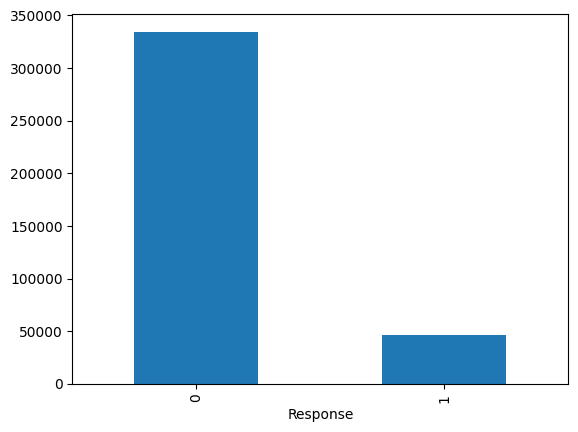

In [8]:
df['Response'].value_counts().plot(kind='bar')

<Axes: xlabel='Gender', ylabel='count'>

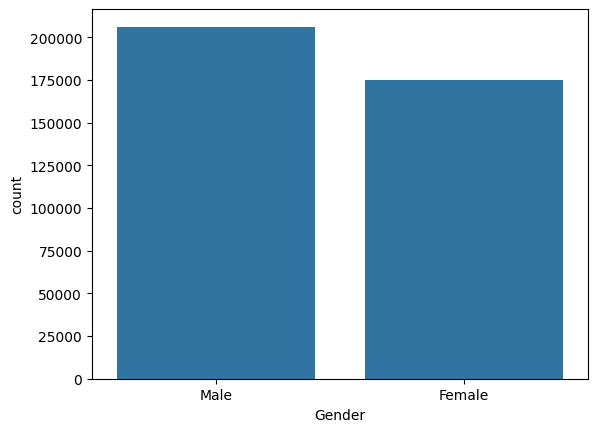

In [9]:
sns.countplot(data=df,x='Gender')

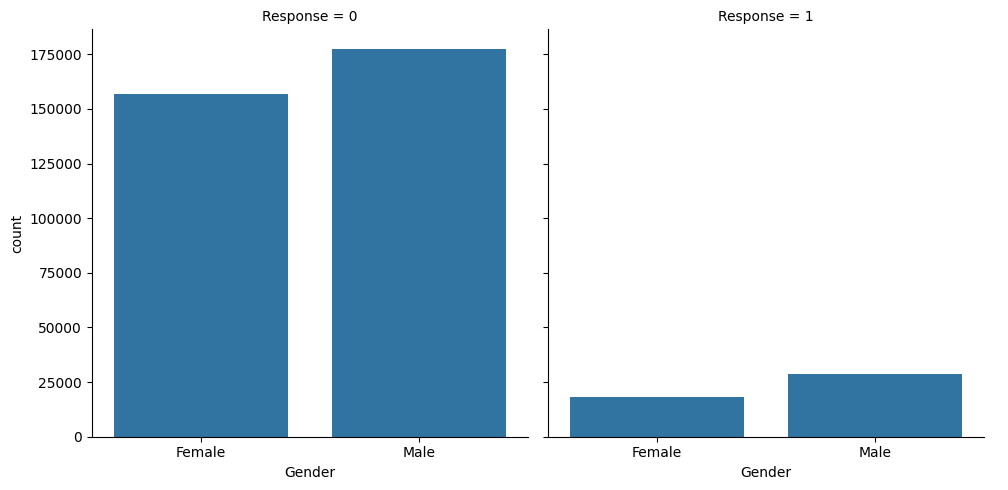

In [10]:
data=df.groupby(['Gender','Response'])['id'].count().to_frame().rename(columns={'id':'count'}).reset_index()
sns.catplot(data=data,x='Gender',y='count',col='Response',kind='bar')

<Axes: xlabel='Response', ylabel='Annual_Premium'>

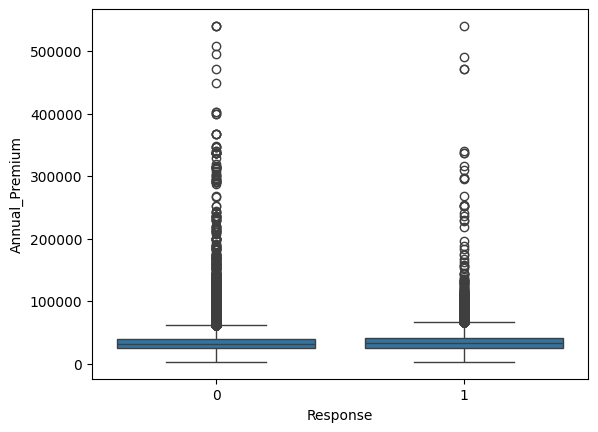

In [11]:
sns.boxplot(data=df,x='Response',y='Annual_Premium')

<Axes: xlabel='Age', ylabel='Annual_Premium'>

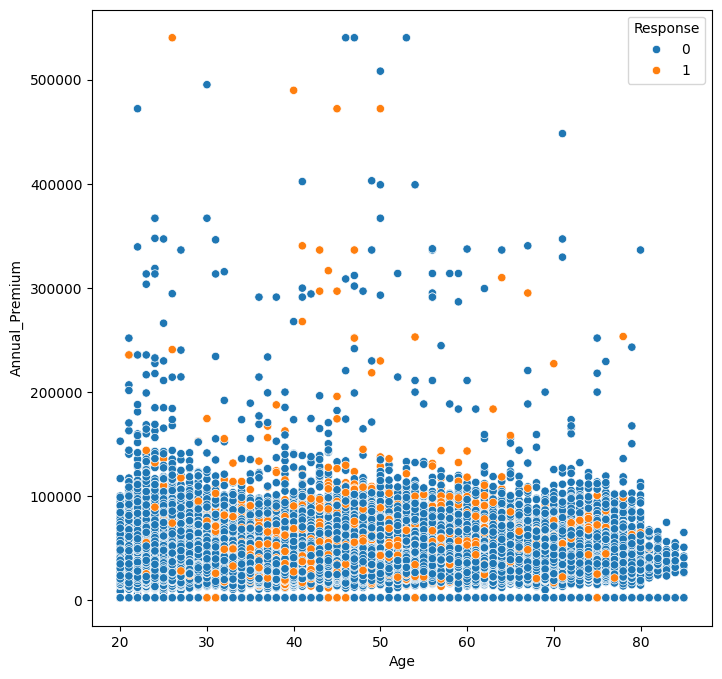

In [12]:
plt.figure(figsize=(8,8))
sns.scatterplot(data=df,x='Age',y='Annual_Premium',hue='Response')

<Axes: xlabel='Previously_Insured', ylabel='count'>

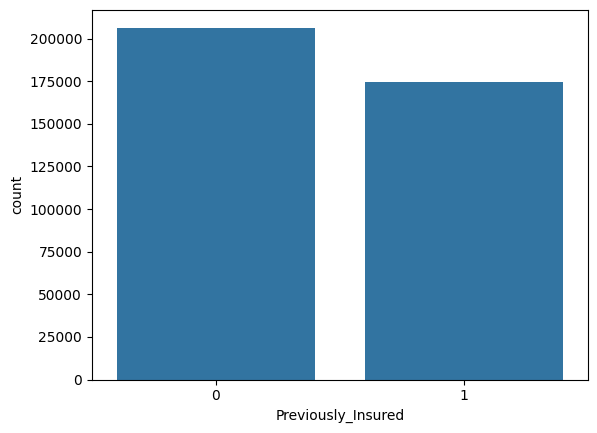

In [13]:
sns.countplot(data=df,x='Previously_Insured')

In [14]:
df['Vehicle_Damage'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [15]:
df.drop(columns=['id'],inplace=True)


In [16]:

df['Gender']=df['Gender'].map({
    'Male':1,
    'Female':0
})
df['Vehicle_Damage']=df['Vehicle_Damage'].map({
    'Yes':1,
    'No':0
})
df=pd.get_dummies(data=df,columns=['Vehicle_Age'],drop_first=True)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years
0,1,44,1,28.0,0,1,40454.0,26.0,217,1,False,True
1,1,76,1,3.0,0,0,33536.0,26.0,183,0,False,False
2,1,47,1,28.0,0,1,38294.0,26.0,27,1,False,True
3,1,21,1,11.0,1,0,28619.0,152.0,203,0,True,False
4,0,29,1,41.0,1,0,27496.0,152.0,39,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
381104,1,74,1,26.0,1,0,30170.0,26.0,88,0,False,False
381105,1,30,1,37.0,1,0,40016.0,152.0,131,0,True,False
381106,1,21,1,30.0,1,0,35118.0,160.0,161,0,True,False
381107,0,68,1,14.0,0,1,44617.0,124.0,74,0,False,True


In [18]:
X=df.drop(columns='Response')
y=df['Response']

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi=mutual_info_classif(X_train,y_train,random_state=42)
mi_df=pd.DataFrame(mi,columns=['MI_Score'])



array([0.05285718, 0.03076444, 0.07341994, 0.01719061, 0.13217322,
       0.11936701, 0.0031924 , 0.05785008, 0.        , 0.06776416,
       0.00510051])

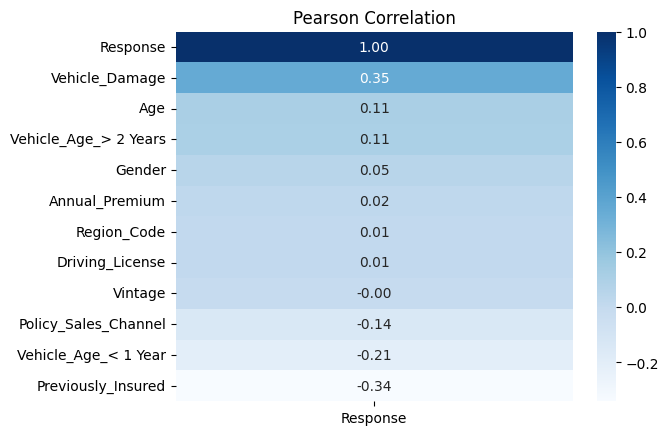

In [29]:
target='Response'
corr_with_target = df.corr()[[target]].sort_values(by=target,ascending=False)
sns.heatmap(corr_with_target,cmap='Blues',annot=True,fmt='.2f')
plt.title('Pearson Correlation')
plt.show()


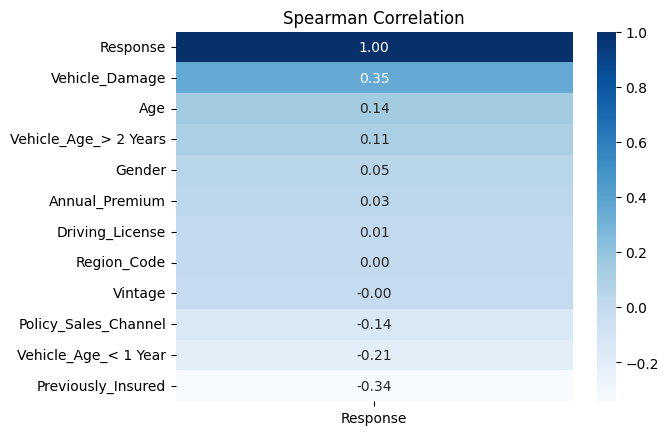

In [28]:
target='Response'
corr_with_target = df.corr(method='spearman')[[target]].sort_values(by=target,ascending=False)
sns.heatmap(corr_with_target,cmap='Blues',annot=True,fmt='.2f')
plt.title('Spearman Correlation')
plt.show()